#### Load the Dataset

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

path_train = "/home/sarantis/Documents/Διπλωματική Εργασία/Diploma-Thesis/PV_dataset/datasets/train data.csv"  
train_data = pd.read_csv(path_train, delimiter=';')

path_test = "/home/sarantis/Documents/Διπλωματική Εργασία/Diploma-Thesis/PV_dataset/datasets/test data.csv"  
test_data = pd.read_csv(path_test, delimiter=';')

display(train_data.head(5))
display(test_data.head(5))

,I1,I2,I1MAX,I1MIN,I1VAR,I2MAX,I2MIN,I2VAR,I3,I4,...,Vdcmax1,Vdcmin1,Pdcmean1,IR,T,range 1,range 2,range 3,range 4,class
0,3.464132,3.464132,3.776515,3.433125,0.000054,3.776515,3.433125,0.000054,3.755050,3.755050,...,514.369415,509.002655,169.603373,660,22,0.343390,0.343390,1.332270e-14,5.773160e-15,1
1,2.244766,2.244766,2.611714,2.210978,0.000350,2.611714,2.210978,0.000350,2.572122,2.572122,...,521.970593,503.241431,116.954097,450,15,0.400736,0.400736,1.554310e-14,0.000000e+00,1
2,3.878360,3.878360,4.101282,3.854098,0.000010,4.101282,3.854098,0.000010,4.094577,4.094577,...,511.837039,509.378912,184.213307,720,24,0.247183,0.247183,2.131630e-14,7.105430e-15,1
3,2.816389,2.816389,3.285793,2.758149,0.000192,3.285793,2.758149,0.000192,3.247759,3.247759,...,518.028478,507.378348,147.283635,570,19,0.527644,0.527644,1.199040e-14,1.332270e-14,1
4,1.238798,1.238798,5.455667,0.141519,0.001153,5.455667,0.141519,0.001153,5.465640,5.465640,...,500.827418,500.127036,238.608844,960,32,5.314147,5.314147,2.442490e-14,2.042810e-14,1


,I1,I2,I1MAX,I1MIN,I1VAR,I2MAX,I2MIN,I2VAR,I3,I4,...,Vdcmax1,Vdcmin1,Pdcmean1,IR,T,range 1,range 2,range 3,range 4,class
0,2.79120,3.0740,3.0704,2.54180,0.060570,3.1119,3.00330,0.001416,3.0158,3.0158,...,506.76,483.08,132.930,526,26,0.52860,0.10860,-0.28280,0.0,2
1,3.45340,3.6386,3.6218,3.31490,0.018449,3.6889,3.56890,0.002442,3.5794,3.5794,...,500.68,489.94,157.050,627,31,0.30690,0.12000,-0.18520,0.0,2
2,1.95250,2.0837,2.3345,1.84450,0.012447,2.3366,2.03480,0.001690,2.0466,2.0466,...,492.02,475.91,88.824,357,33,0.49000,0.30180,-0.13120,0.0,2
3,2.40180,2.5785,2.5868,2.25420,0.021388,2.6087,2.51950,0.000998,2.5323,2.5323,...,500.54,476.94,110.530,442,29,0.33260,0.08920,-0.17670,0.0,2
4,0.85467,1.0284,2.3547,0.51656,0.211560,2.3567,0.86222,0.129860,1.0164,1.0164,...,509.73,476.00,46.718,148,11,1.83814,1.49448,-0.17373,0.0,2


#### Exploratory Analysis 

In [19]:
missing_values_train = train_data.isnull().sum()  # missing values
if missing_values_train.sum() == 0:
    print("No missing values found.")
else:
    print("Missing values:")
    print(missing_values_train)

missing_values_test = test_data.isnull().sum()
if missing_values_test.sum() == 0:
    print("No missing values found.")
else:
    print("Missing values:")
    print(missing_values_test)

No missing values found.
No missing values found.


#### Γραφική Απεικόνιση της Κλάσης 'Class' 

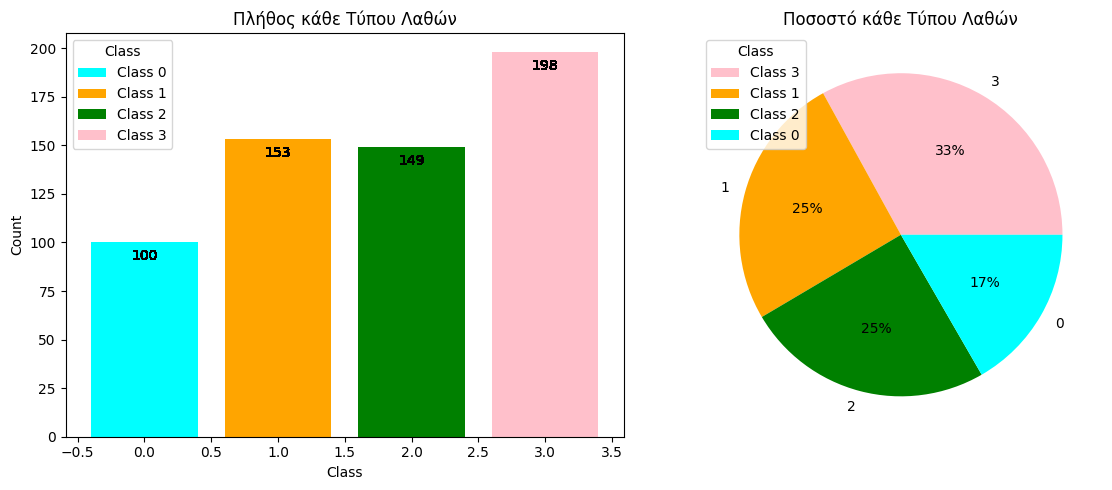

In [20]:
class_colors = {0: 'cyan', 1: 'orange', 2: 'green', 3: 'pink'}

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axs[0].set_title('Πλήθος κάθε Τύπου Λαθών')
for c, color in class_colors.items():
    subset = train_data[train_data['class'] == c]
    axs[0].bar(subset['class'], subset['class'].count(), color=color, label=f'Class {c}')

for p in axs[0].patches:
    height = p.get_height()
    axs[0].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', xytext=(0, -10), textcoords='offset points', fontsize=10, color='black')

axs[0].set_xlabel('Class')
axs[0].set_ylabel('Count')
axs[0].legend(labels=[f'Class {c}' for c in class_colors], title='Class')

axs[1].set_title('Ποσοστό κάθε Τύπου Λαθών')
value = train_data['class'].value_counts()
class_percentage = 100 * value / train_data['class'].shape[0]
labels = class_percentage.index.array
x = class_percentage.array

axs[1].pie(x, labels=labels, colors=[class_colors[c] for c in labels], autopct='%.0f%%')
axs[1].legend(labels=[f'Class {c}' for c in labels], title='Class', loc='upper left')

plt.tight_layout()
plt.show()

#### Outliers Inspection

In [21]:
train_data.describe()

,I1,I2,I1MAX,I1MIN,I1VAR,I2MAX,I2MIN,I2VAR,I3,I4,...,Vdcmax1,Vdcmin1,Pdcmean1,IR,T,range 1,range 2,range 3,range 4,class
count,600.000000,600.000000,600.000000,600.000000,6.000000e+02,600.000000,600.000000,6.000000e+02,600.000000,600.000000,...,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,6.000000e+02,6.000000e+02,600.000000
mean,2.168802,2.702196,3.171884,2.065798,1.125053e-02,3.201553,2.628476,9.431151e-03,3.173297,3.090828,...,510.429886,502.345005,141.320366,552.196667,22.118333,1.106086,0.573077,-5.333941e-01,8.246940e-02,1.741667
std,6.749492,6.093503,1.446764,7.146948,1.634520e-01,1.461743,6.481825,1.608909e-01,1.450554,1.430920,...,12.613528,8.586523,65.611833,253.865300,7.449171,7.171965,6.436240,3.151654e+00,2.834775e-01,1.089453
min,-99.256851,-99.256851,0.600371,-106.199598,1.310000e-07,0.600371,-106.199598,3.670000e-08,0.603565,0.603565,...,475.940000,473.430000,25.492978,106.000000,10.000000,0.001930,0.001930,-6.658520e+01,0.000000e+00,0.000000
25%,1.441450,1.801175,1.932475,1.395700,9.400000e-06,1.959100,1.773075,3.986800e-06,1.930000,1.871300,...,501.015000,496.524177,85.831000,334.750000,16.000000,0.095250,0.029400,-3.603175e-01,0.000000e+00,1.000000
50%,2.649600,3.026500,3.083400,2.591750,7.206625e-05,3.122793,2.975650,1.956450e-05,3.098803,3.034550,...,510.071482,503.005000,136.060000,537.000000,22.000000,0.250583,0.063000,-8.005000e-02,5.773160e-15,2.000000
75%,3.878670,4.318025,4.427850,3.870075,3.556675e-04,4.443775,4.254050,1.629350e-04,4.432325,4.307300,...,520.297136,508.585000,196.652500,775.250000,28.000000,0.518113,0.174125,0.000000e+00,8.080000e-02,3.000000
max,5.664400,5.890400,5.754700,5.653200,2.789173e+00,5.905500,5.756000,2.789173e+00,5.840000,5.688400,...,533.490000,517.827997,263.570000,1000.000000,35.000000,111.471608,111.471608,5.773160e-14,3.613700e+00,3.000000


/home/sarantis/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


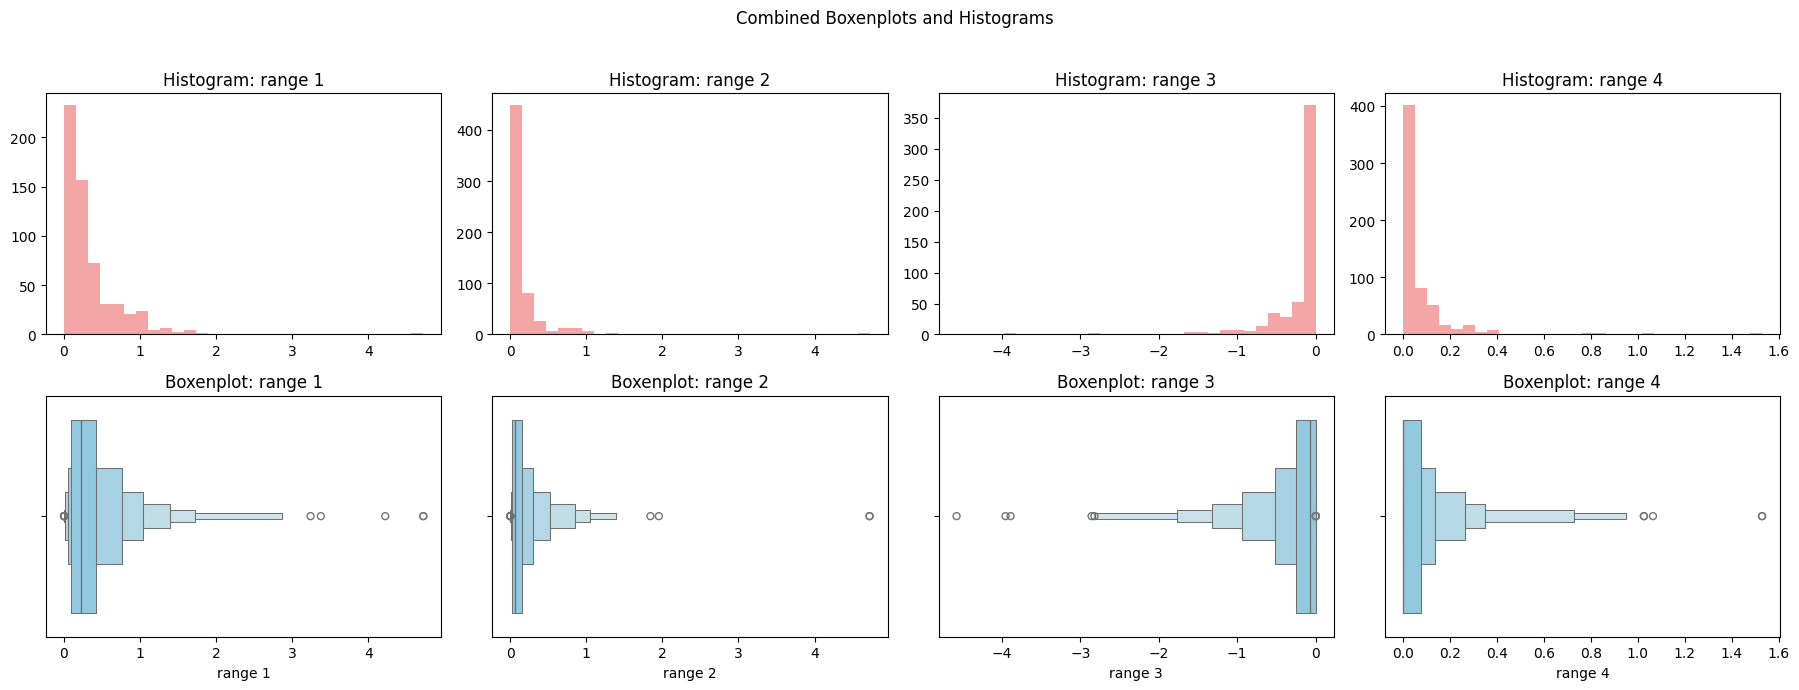

In [22]:
num_features = ['range 1', 'range 2', 'range 3', 'range 4']

num_features = [feature for feature in num_features if train_data[feature].dtype == 'float64']
#train_data[num_features] = train_data[num_features].apply(lambda x: np.where(x <= 0, np.nan, x))

log_transformed_data = train_data[num_features].apply(lambda x: np.log1p(x))

fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(18, 7))
fig.suptitle('Combined Boxenplots and Histograms')

for j, feature in enumerate(num_features):
    axs[0, j].hist(log_transformed_data[feature], bins=30, color='lightcoral', alpha=0.7)
    axs[0, j].set_title(f'Histogram: {feature}')

    sns.boxenplot(ax=axs[1, j], data=log_transformed_data, x=feature, color='skyblue')
    axs[1, j].set_title(f'Boxenplot: {feature}')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### Feature Distribution

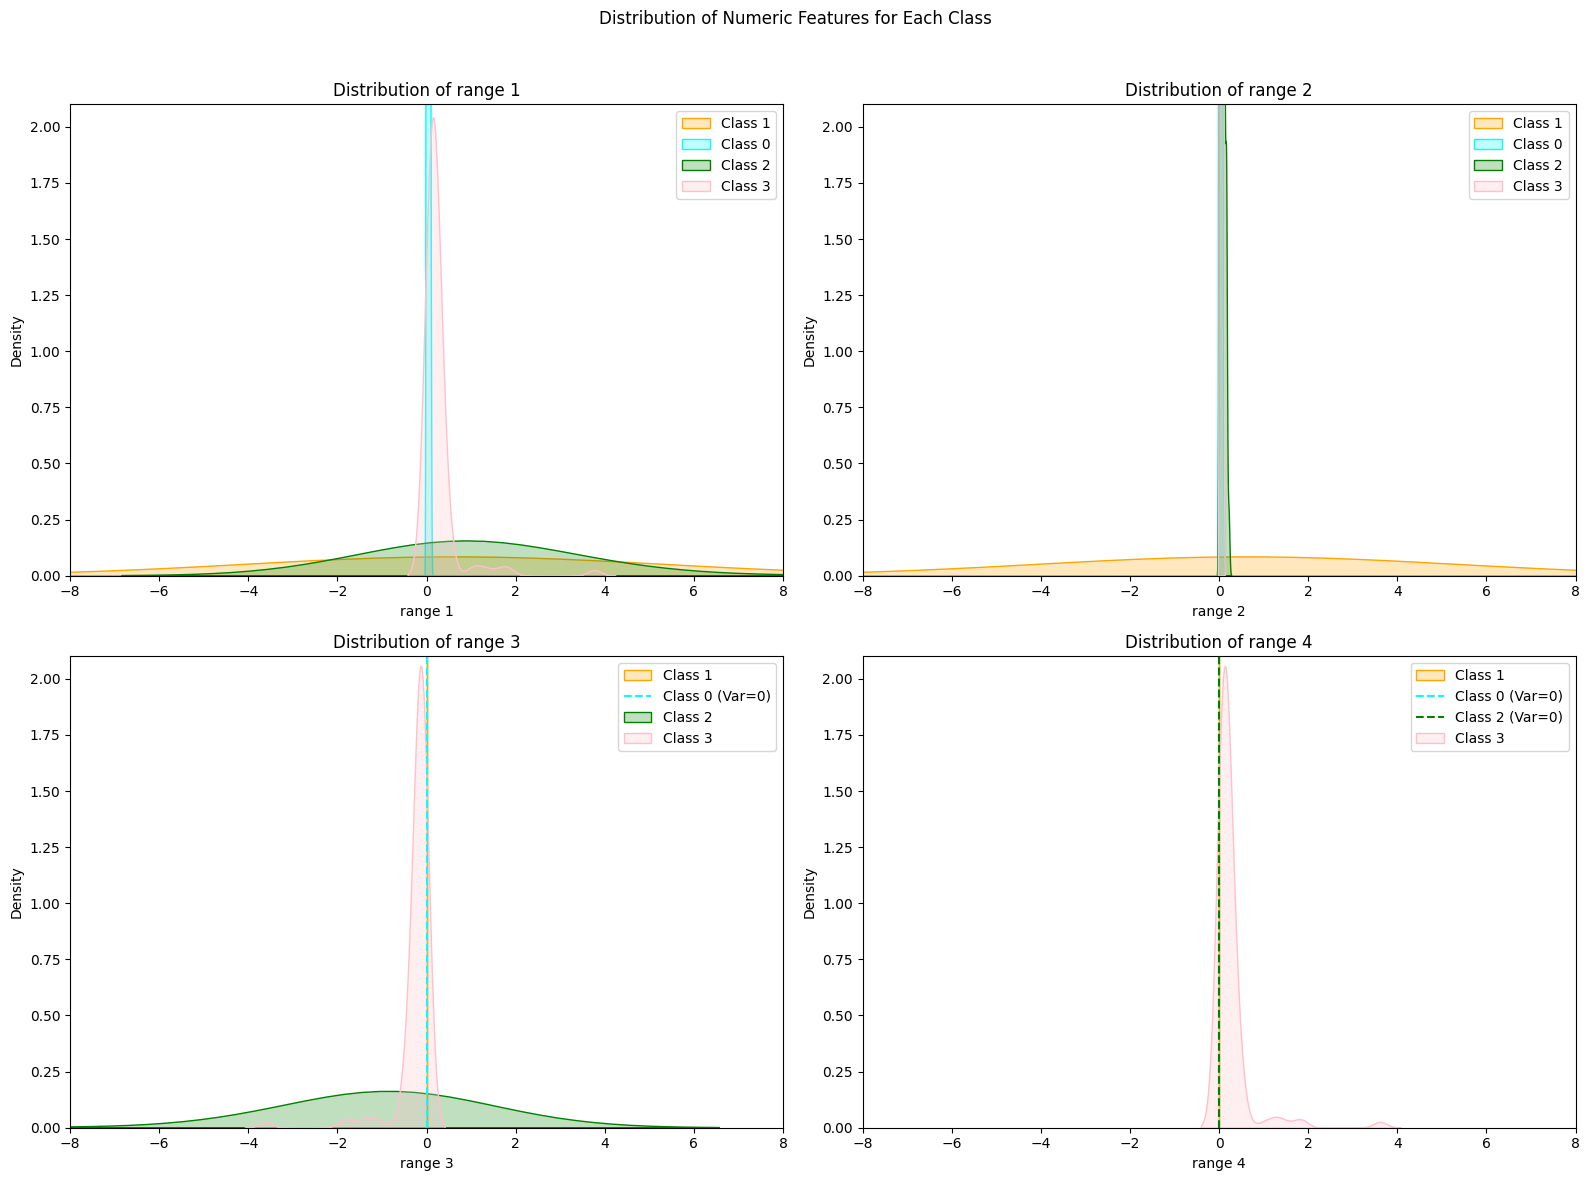

In [23]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
fig.suptitle('Distribution of Numeric Features for Each Class')

for i, num_feature in enumerate(num_features):
    ax = axs[i//2, i%2]
    for c in train_data['class'].unique():
        subset = train_data[train_data['class'] == c][num_feature]
        if subset.var() == 0:
            ax.axvline(x=subset.iloc[0], linestyle='dashed', color=class_colors[c], label=f'Class {c} (Var=0)')
        else:
            sns.kdeplot(data=subset, fill=True, label=f'Class {c}', color=class_colors[c], ax=ax)

    ax.set_title(f'Distribution of {num_feature}')
    ax.set_xlabel(num_feature)
    ax.set_ylabel('Density')
    ax.legend()
    ax.set_xlim(-8, 8)
    ax.set_ylim(0, 2.1)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [24]:
num_features = train_data.select_dtypes(include=['float64', 'int64']).columns

pca = PCA(n_components=len(num_features))

X_pca = pd.DataFrame(data=pca.fit_transform(train_data[num_features]), columns=['PC'+str(i+1) for i in range(len(num_features))])

var_exp = pd.Series(data=100*pca.explained_variance_ratio_, index=['PC'+str(i+1) for i in range(len(num_features))])
print('Explained variance ratio per component:', round(var_exp, 2)[:15], sep='\n')
print('Explained variance ratio with 6 components: '+str(round(var_exp.values[:6].sum(), 2)))

Explained variance ratio per component:
PC1     97.89
PC2      1.20
PC3      0.44
PC4      0.36
PC5      0.04
PC6      0.04
PC7      0.03
PC8      0.01
PC9      0.00
PC10     0.00
PC11     0.00
PC12     0.00
PC13     0.00
PC14     0.00
PC15     0.00
dtype: float64
Explained variance ratio with 6 components: 99.96


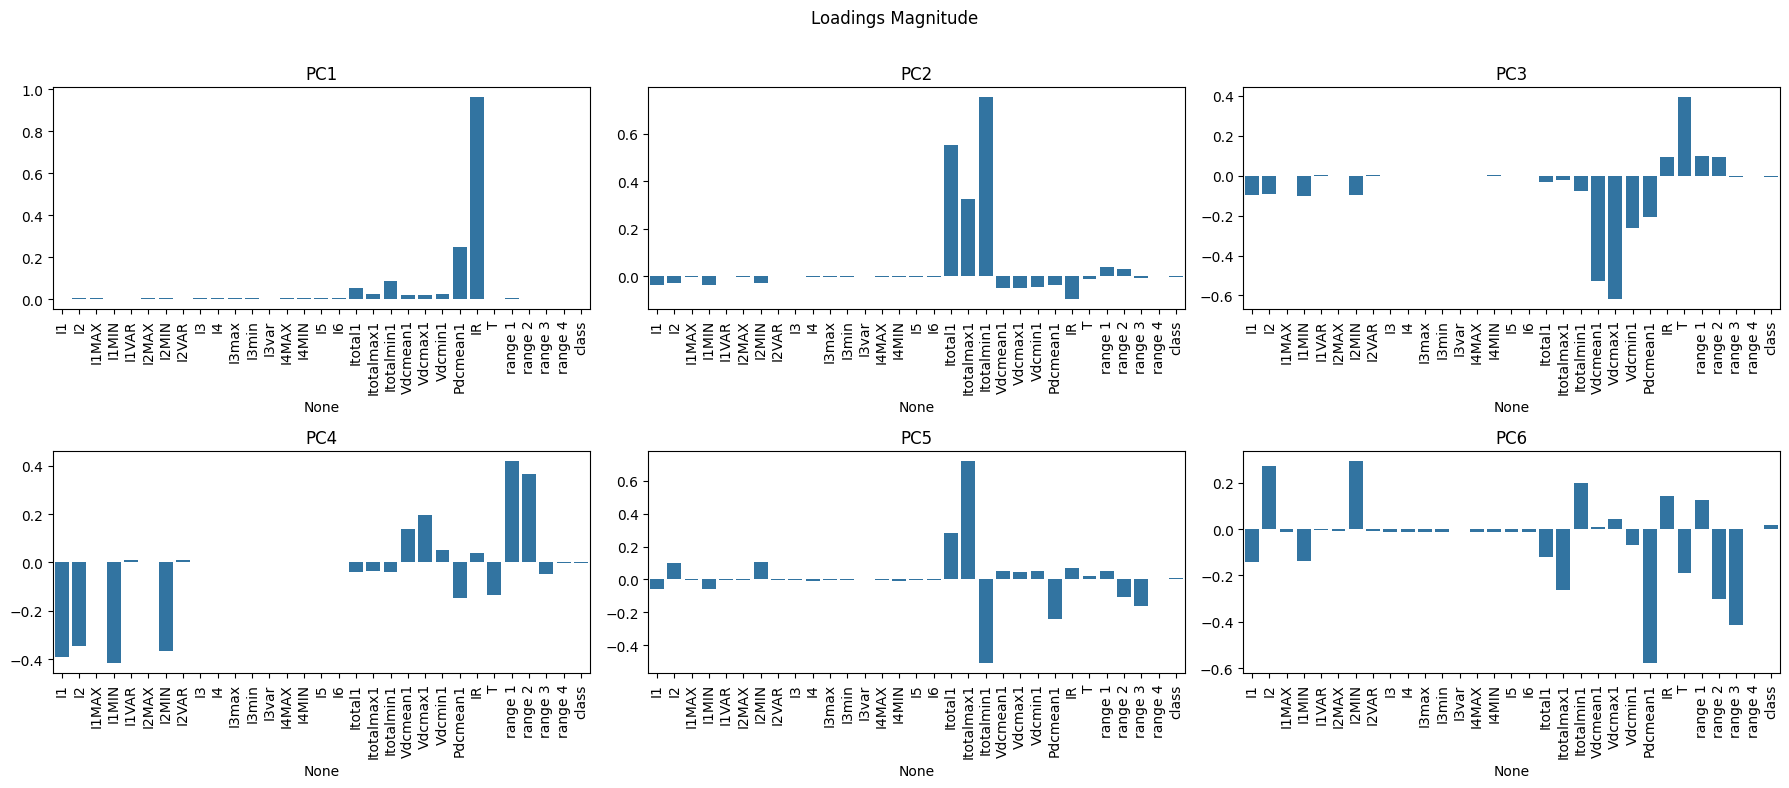

In [25]:
num_features = train_data.select_dtypes(include=['float64', 'int64']).columns

pca6 = PCA(n_components=6)
X_pca6 = pd.DataFrame(data=pca6.fit_transform(train_data[num_features]), columns=['PC'+str(i+1) for i in range(6)])

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 8))
fig.suptitle('Loadings Magnitude')

pca_loadings = pd.DataFrame(data=pca6.components_, columns=num_features)

for i in range(2):
    for j in range(3):
        ax = axs[i, j]
        pc_index = i * 3 + j
        sns.barplot(ax=ax, x=pca_loadings.columns, y=pca_loadings.values[pc_index])
        ax.tick_params(axis='x', rotation=90)
        ax.title.set_text('PC'+str(pc_index+1))

plt.tight_layout(rect=[0, 0, 1, 0.97]) 
plt.show()

#### Prepare the Dataset

In [26]:
# Ένωση των δύο dataframe(train & test) 
combined_data = pd.concat([train_data, test_data], axis=0, ignore_index=True)

# Check for missing values
missing_values_train = train_data.isnull().sum()
if missing_values_train.sum() == 0:
    print("No missing values found.")
else:
    print("Missing values:")
    print(missing_values_train)

missing_values_test = test_data.isnull().sum()
if missing_values_test.sum() == 0:
    print("No missing values found.")
else:
    print("Missing values:")
    print(missing_values_test)

missing_values_test = combined_data.isnull().sum()
if missing_values_test.sum() == 0:
    print("No missing values found.")
else:
    print("Missing values:")
    print(missing_values_test)  

No missing values found.
No missing values found.
No missing values found.


#### X,y dataset

In [27]:
# Dataframe without class
X_train = train_data.drop('class', axis=1) 
X_test = test_data.drop('class', axis=1)
# Dataframe for Target Variable
y_train = train_data['class']  
y_test = test_data['class']

# Dataframe without class
X_dataset = combined_data.drop('class', axis=1)
# Dataframe for Target Variable
y_dataset = combined_data['class']

##### SMOTE

In [28]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Class distribution after oversampling:\n", y_train_resampled.value_counts())

Class distribution after oversampling:
 1    198
0    198
2    198
3    198
Name: class, dtype: int64


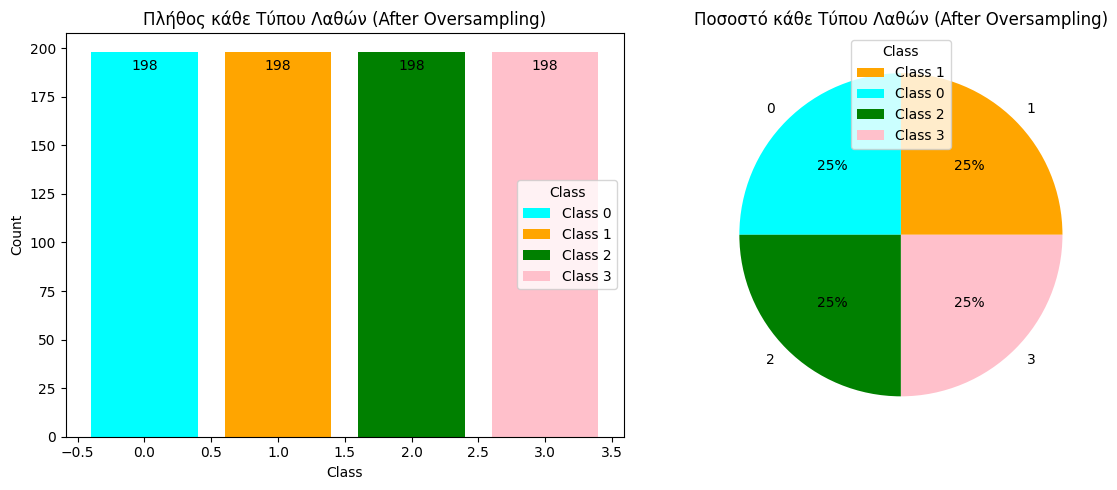

In [29]:
class_colors_resampled = {0: 'cyan', 1: 'orange', 2: 'green', 3: 'pink'}

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].set_title('Πλήθος κάθε Τύπου Λαθών (After Oversampling)')
for c, color in class_colors_resampled.items():
    subset = y_train_resampled[y_train_resampled == c]
    axs[0].bar(c, len(subset), color=color, label=f'Class {c}')

for p in axs[0].patches:
    height = p.get_height()
    axs[0].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', xytext=(0, -10), textcoords='offset points', fontsize=10, color='black')

axs[0].set_xlabel('Class')
axs[0].set_ylabel('Count')
axs[0].legend(labels=[f'Class {c}' for c in class_colors_resampled], title='Class', loc='center right')

axs[1].set_title('Ποσοστό κάθε Τύπου Λαθών (After Oversampling)')
value_resampled = pd.Series(y_train_resampled).value_counts()
class_percentage_resampled = 100 * value_resampled / len(y_train_resampled)
labels_resampled = class_percentage_resampled.index.array
x_resampled = class_percentage_resampled.array

axs[1].pie(x_resampled, labels=labels_resampled, colors=[class_colors_resampled[c] for c in labels_resampled], autopct='%.0f%%')
axs[1].legend(labels=[f'Class {c}' for c in labels_resampled], title='Class', loc='upper center')

plt.tight_layout()
plt.show()

#### Min-Max Scaling

In [30]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
X_scaled = pd.DataFrame(scaler.fit_transform(X_dataset), columns=X_dataset.columns)
X_resampled_scaled = pd.DataFrame(scaler.fit_transform(X_train_resampled), columns=X_train_resampled.columns)

display(X_train_scaled.head(5))
display(X_test_scaled.head(5))

,I1,I2,I1MAX,I1MIN,I1VAR,I2MAX,I2MIN,I2VAR,I3,I4,...,Vdcmean1,Vdcmax1,Vdcmin1,Pdcmean1,IR,T,range 1,range 2,range 3,range 4
0,0.979029,0.976925,0.616209,0.980152,0.000019,0.598693,0.979252,0.000019,0.601838,0.619781,...,0.715087,0.667757,0.801222,0.605310,0.619687,0.48,0.003063,0.003063,1.0,1.597576e-15
1,0.967408,0.965328,0.390224,0.969225,0.000126,0.379132,0.968335,0.000126,0.375934,0.387143,...,0.776950,0.799837,0.671459,0.384166,0.384787,0.20,0.003578,0.003578,1.0,0.000000e+00
2,0.982977,0.980865,0.679218,0.983915,0.000004,0.659911,0.983012,0.000004,0.666677,0.686554,...,0.677939,0.623754,0.809697,0.666676,0.686801,0.56,0.002200,0.002200,1.0,1.966248e-15
3,0.972856,0.970765,0.521003,0.974117,0.000069,0.506194,0.973223,0.000069,0.504961,0.520016,...,0.755324,0.731338,0.764637,0.511560,0.519016,0.36,0.004716,0.004716,1.0,3.686720e-15
4,0.957820,0.955761,0.941984,0.950724,0.000413,0.915208,0.949851,0.000413,0.928509,0.956191,...,0.477674,0.432449,0.601312,0.895155,0.955257,0.88,0.047656,0.047656,1.0,5.652960e-15


,I1,I2,I1MAX,I1MIN,I1VAR,I2MAX,I2MIN,I2VAR,I3,I4,...,Vdcmean1,Vdcmax1,Vdcmin1,Pdcmean1,IR,T,range 1,range 2,range 3,range 4
0,0.972616,0.973215,0.479214,0.972183,0.021716,0.473415,0.975413,0.000508,0.460664,0.474398,...,0.484972,0.535534,0.217352,0.451270,0.469799,0.64,0.004725,0.000957,0.995753,0.0
1,0.978927,0.978584,0.586193,0.979095,0.006614,0.582178,0.980465,0.000876,0.568294,0.585237,...,0.443928,0.429887,0.371864,0.552582,0.582774,0.84,0.002736,0.001059,0.997219,0.0
2,0.964622,0.963796,0.336441,0.965949,0.004463,0.327274,0.966762,0.000606,0.275576,0.283792,...,0.266069,0.279409,0.055858,0.266011,0.280761,0.92,0.004379,0.002690,0.998030,0.0
3,0.968904,0.968502,0.385390,0.969612,0.007668,0.378564,0.971091,0.000358,0.368330,0.379311,...,0.389202,0.427454,0.079058,0.357183,0.375839,0.76,0.002966,0.000783,0.997346,0.0
4,0.954159,0.953760,0.340360,0.954077,0.075850,0.331062,0.956288,0.046559,0.078839,0.081189,...,0.323675,0.587142,0.057885,0.089152,0.046980,0.04,0.016473,0.013390,0.997391,0.0


#### Store the Values

In [31]:
%store X_train_scaled
%store X_train
%store y_train
%store X_test_scaled
%store X_test
%store y_test
%store X_scaled
%store y_dataset
%store X_resampled_scaled
%store y_train_resampled

Stored 'X_train_scaled' (DataFrame)
Stored 'X_train' (DataFrame)
Stored 'y_train' (Series)
Stored 'X_test_scaled' (DataFrame)
Stored 'X_test' (DataFrame)
Stored 'y_test' (Series)
Stored 'X_scaled' (DataFrame)
Stored 'y_dataset' (Series)
Stored 'X_resampled_scaled' (DataFrame)
Stored 'y_train_resampled' (Series)


In [33]:
import os
if not os.path.exists('datasets'):
    os.makedirs('datasets')

# Save dataframes to CSV files in the 'datasets' folder
X_train.to_csv('datasets/X_train.csv', index=False)
X_test.to_csv('datasets/X_test.csv', index=False)
y_train.to_csv('datasets/y_train.csv', index=False)
y_test.to_csv('datasets/y_test.csv', index=False)
combined_data.to_csv('datasets/combined_data.csv', index=False)
X_dataset.to_csv('datasets/X_dataset.csv', index=False)
y_dataset.to_csv('datasets/y_dataset.csv', index=False)
X_resampled_scaled.to_csv('datasets/X_resampled_scaled', index=False)
y_train_resampled.to_csv('datasets/y_train_resapmled', index=False)